In [40]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
import matplotlib as mpl
pd.options.mode.chained_assignment = None


eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_p2d/"
res_DIR = "../data/results_p2d/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [41]:
cell = 1

In [42]:
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)

In [43]:
sno = 0

# DFN

In [44]:
dfn = pybamm.lithium_ion.DFN(
    {
        # "SEI": "ec reaction limited",
        # "loss of active material": "stress-driven",
        # "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
        "particle mechanics":"swelling only",
    }
)
param=dfn.param
parameter_values = get_parameter_values()   
# sim_des = sim_des+'_cv'
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
Ns = np.insert(N_0[1:]-1,0,0)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,dfn,parameter_values)
c_rate_c = '1.5C'
c_rate_d = '1.5C'
pybamm.set_logging_level("WARNING")
par_val = {}
# Room temp
par_val[0] = [4.0312e-08,1.8157e-07,1.0776,2.3586e-09,-4.9170e-09,-1.4406e-09,4.60788219e-16,4.56607447e-19]
parameter_values = get_parameter_values()
parameter_values.update(
    {   
        "Positive electrode diffusion coefficient activation energy [J.mol-1]": 0,
        "Negative electrode diffusion coefficient activation energy [J.mol-1]": 0,
        "Positive electrode reference exchange-current density activation energy [J.mol-1]": 0,
        "Negative electrode reference exchange-current density activation energy [J.mol-1]": 0,
        "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
        "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
        "Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]": 3.377e-06,
        "Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]":	3.183e-06,
        "Negative electrode active material volume fraction": eps_n_data,
        "Positive electrode active material volume fraction": eps_p_data,
        "Initial temperature [K]": 273.15+Temp,
        "Ambient temperature [K]": 273.15+Temp,
        "Positive electrode LAM constant proportional term [s-1]": par_val[sno][0],
        "Negative electrode LAM constant proportional term [s-1]": par_val[sno][1],
        "Positive electrode LAM constant proportional term 2 [s-1]": par_val[sno][5],
        "Negative electrode LAM constant proportional term 2 [s-1]": par_val[sno][4],
        "Positive electrode LAM constant exponential term": par_val[sno][2],
        "Negative electrode LAM constant exponential term": par_val[sno][2],
        "SEI kinetic rate constant [m.s-1]":  par_val[sno][6], #1.08494281e-16 , 
        "EC diffusivity [m2.s-1]": par_val[sno][7],#8.30909086e-19,
        "SEI growth activation energy [J.mol-1]": 1.87422275e+04,#1.58777981e+04,
        "Lithium plating kinetic rate constant [m.s-1]": par_val[sno][3],
        "Initial inner SEI thickness [m]": 0e-09,
        "Initial outer SEI thickness [m]": 5e-09,
        "Li plating resistivity [Ohm.m]": 30000,
        "SEI resistivity [Ohm.m]": 30000.0,
        "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,
        # "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
        # "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
        # "Negative electrode critical stress [Pa]": 20e+06,
        # "Positive electrode critical stress [Pa]": 40e+06,
    },
    check_already_exists=False,
)
if cell == 13 or cell == 16:
    parameter_values.update(
        {
            "Negative electrode partial molar volume [m3.mol-1]":	0.747*7e-06,
        },
        check_already_exists=False,
    )

experiment = pybamm.Experiment(
    [
        ("Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/100",
        "Discharge at "+c_rate_d+dis_set,)
    ],
    termination="50% capacity",
)
SOC_0 = 0
sols = []
parameter_values.update(
    {
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,

    },
    check_already_exists=False,
)

In [45]:
sim_long = pybamm.Simulation(dfn, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe", rtol=1e-5, atol=1e-6,dt_max=0.1))
sol1 = sim_long.solve(initial_soc=SOC_0)

At t = 0.00215235 and h = 1.0377e-018, the corrector convergence failed repeatedly or with |h| = hmin.


## SEI

### Parameters

In [46]:
parameter_values.search("thickness")

Initial inner SEI thickness [m]	0.0
Initial outer SEI thickness [m]	5e-09
Negative current collector thickness [m]	2.5e-05
Negative electrode thickness [m]	6.2e-05
Positive current collector thickness [m]	2.5e-05
Positive electrode thickness [m]	6.7e-05
Separator thickness [m]	1.2e-05


In [47]:
R_sei = parameter_values["SEI resistivity [Ohm.m]"]
R_plated_Li = parameter_values["Li plating resistivity [Ohm.m]"]
C_sei_ec = parameter_values["EC initial concentration in electrolyte [mol.m-3]"]
D_sei = parameter_values["EC diffusivity [m2.s-1]"]
k_sei0 = parameter_values["SEI kinetic rate constant [m.s-1]"]
E_seia = parameter_values["SEI growth activation energy [J.mol-1]"]
T_ref  = parameter_values["Reference temperature [K]"]
R = parameter_values.evaluate(param.R)
F = parameter_values.evaluate(param.F)
alp_pl = parameter_values["Lithium plating transfer coefficient"]
alp_sei = 0.5
k_pl0 = parameter_values["Lithium plating kinetic rate constant [m.s-1]"]
U_pl = parameter_values["Li plating open-circuit potential [V]"]
U_sei = parameter_values["SEI open-circuit potential [V]"]
R_p_n = parameter_values["Negative particle radius [m]"]
e_s_n_0 = parameter_values["Negative electrode active material volume fraction"]
a_s_n_0 = 3*parameter_values["Negative electrode active material volume fraction"]/R_p_n
omega_sei = parameter_values["Inner SEI partial molar volume [m3.mol-1]"]
A = parameter_values["Cell cooling surface area [m2]"]
l_n = parameter_values["Negative electrode thickness [m]"]
delta_sei_0 = parameter_values["Initial outer SEI thickness [m]"]

### Initial Values

In [48]:
states_lsei = 0
states_lpl = 0
L_sei = states_lsei
L_plated_Li = states_lpl

### Variables

In [49]:
# dfn.variables.search("volume")

In [50]:
t = sol1["Time [s]"].entries
delta_phi = sol1["X-averaged negative electrode surface potential difference [V]"].entries
j = sol1[
        "X-averaged negative"
        + " electrode total interfacial current density [A.m-2]"
    ].entries
T = sol1["X-averaged negative electrode temperature [K]"].entries
c_ss_n = sol1["X-averaged negative particle surface concentration [mol.m-3]"].entries
c_save_n = sol1["R-averaged negative particle concentration [mol.m-3]"].entries
c_save_n = np.average(c_save_n,axis=0)
# c_e_n = sol1["Negative electrolyte concentration [mol.m-3]"].entries
U_p = sol1["X-averaged positive electrode open circuit potential [V]"].entries
U_n = sol1["X-averaged negative electrode open circuit potential [V]"].entries
a_s_n = 3*sol1["X-averaged negative electrode active material volume fraction"].entries/R_p_n

In [51]:
eta_SEI = delta_phi - j * L_sei * R_sei -j * L_plated_Li * R_plated_Li  - U_sei
k_SEI = k_sei0*np.exp(-E_seia*(1-T/T_ref)/R/T_ref)
SEI_exp = k_SEI*np.exp(-alp_sei*F*eta_SEI/R/T)
j_sei = -C_sei_ec*F/(1/SEI_exp+L_sei/D_sei)


In [52]:
c_sei = integrate.cumtrapz(-a_s_n*j_sei/2/F,t)
c_sei = np.insert(c_sei, 0, 0)
delta_sei = c_sei*omega_sei/a_s_n_0 + delta_sei_0

### Side reaction current

In [53]:
i_side = -A*l_n*a_s_n*(j_sei)/2
n_li_loss = integrate.cumtrapz(i_side/F,t)
n_li_loss = np.insert(n_li_loss, 0, 0)

In [54]:
integrate.trapz(i_side,t)

1.0513941480261084

# SPM

In [55]:
spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        # "loss of active material": "stress-driven",
        # "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
        "particle mechanics":"swelling only",
    }
)
param=spm.param

In [56]:
sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe", rtol=1e-2, atol=1e-3,dt_max=1))
sol2 = sim_long.solve(initial_soc=SOC_0)

In [57]:
# spm.variables.search("side")

In [58]:
t_spm = sol2["Time [s]"].entries
n_li_loss_spm = sol2["Loss of lithium to SEI [mol]"].entries
delta_sei_spm = sol2["X-averaged total SEI thickness [m]"].entries
c_ss_n_spm = sol2["X-averaged negative particle surface concentration [mol.m-3]"].entries
c_save_n_spm = sol2["R-averaged negative particle concentration [mol.m-3]"].entries
c_save_n_spm = np.average(c_save_n_spm,axis=0)
j_sei_spm = sol2["X-averaged outer SEI interfacial current density [A.m-2]"].entries
eta_SEI_spm = sol2["X-averaged negative electrode sei reaction overpotential [V]"].entries

In [59]:
max(c_ss_n-c_ss_n_spm)
pybamm.rmse(c_save_n,c_save_n_spm)
# max(c_save_n-c_save_n_spm)

ValueError: operands could not be broadcast together with shapes (97,) (95,) 

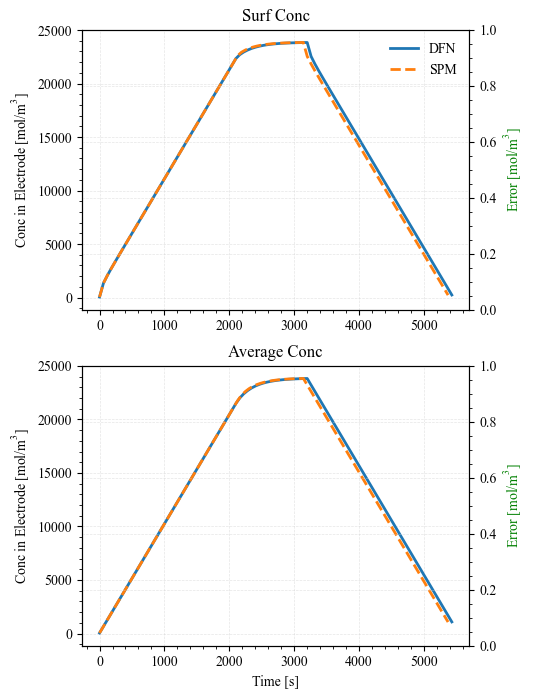

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(t,c_ss_n)
ax1.plot(t_spm,c_ss_n_spm,'--')
ax1.set_title(r"Surf Conc")
ax1.set_ylabel(r"Conc in Electrode [mol/m$^3$]")
ax1.legend(["DFN","SPM"])
ax11 = ax1.twinx()
# ax11.plot(t,c_ss_n-c_ss_n_spm,"g.")
ax11.set_ylabel("Error [mol/m$^3$]",color="g")
ax2 = ax.flat[1]
ax2.plot(t,c_save_n)
ax2.plot(t_spm,c_save_n_spm,'--')
ax2.set_title(r"Average Conc")
ax2.set_ylabel(r"Conc in Electrode [mol/m$^3$]")
ax21 = ax2.twinx()
# ax21.plot(t,c_save_n-c_save_n_spm,"g.")
ax21.set_ylabel("Error [mol/m$^3$]",color="g")
ax2.set_xlabel("Time [s]")
# fig.suptitle("Negative Electrode Concentrations")
fig.savefig(fig_DIR+"single_cycle_comp_concentrations.png")


In [ ]:
pybamm.rmse(j_sei,j_sei_spm)
# max(j_sei-j_sei_spm)A

2.285828210293264e-07

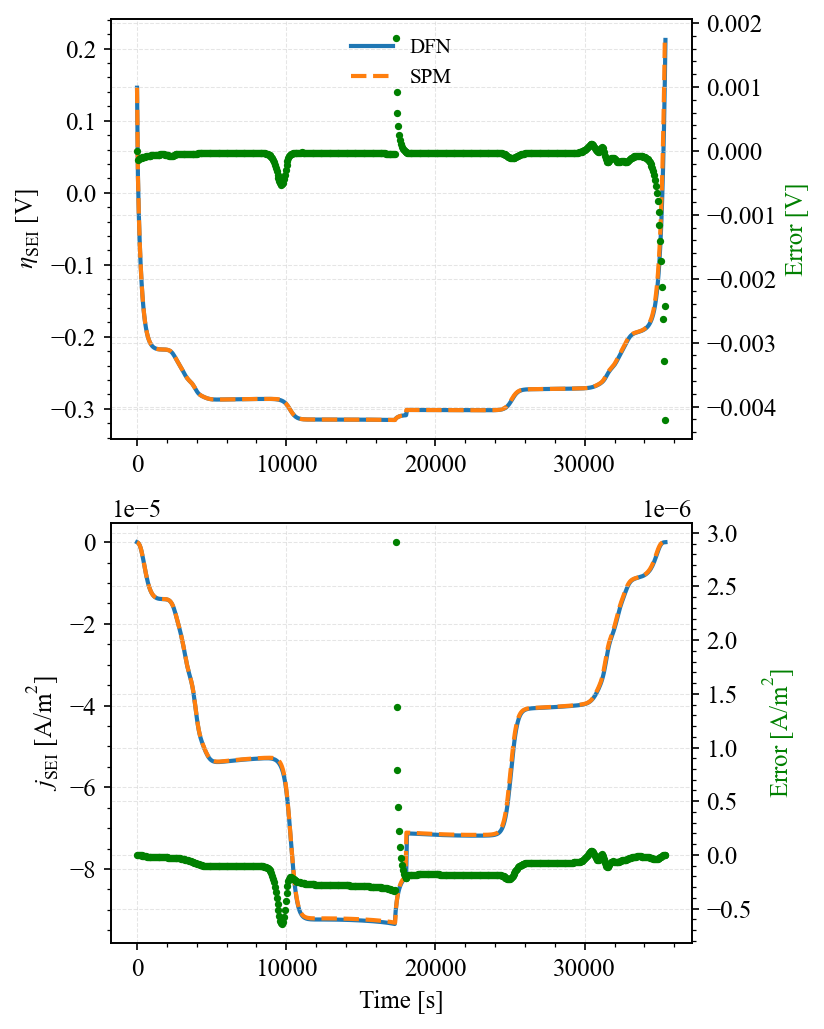

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(t,eta_SEI)
ax1.plot(t_spm,eta_SEI_spm,'--')
ax1.set_ylabel(r"$\eta_\mathrm{SEI}$ [V]")
ax1.legend(["DFN","SPM"])
ax11 = ax1.twinx()
ax11.plot(t,eta_SEI-eta_SEI_spm,"g.")
ax11.set_ylabel("Error [V]",color="g")
ax2 = ax.flat[1]
ax2.plot(t,j_sei)
ax2.plot(t_spm,j_sei_spm,'--')
ax2.set_ylabel(r"$j_\mathrm{SEI}$ [A/m$^2$]")
ax21 = ax2.twinx()
ax21.plot(t,j_sei-j_sei_spm,"g.")
ax21.set_ylabel(r"Error [A/m$^2$]",color="g")
ax2.set_xlabel("Time [s]")
fig.savefig(fig_DIR+"single_cycle_comp_sei_vars_1.png")


In [ ]:
# max(n_li_loss-n_li_loss_spm)
# pybamm.rmse(n_li_loss,n_li_loss_spm)
# max(delta_sei-delta_sei_spm)
pybamm.rmse(delta_sei,delta_sei_spm)

2.5803941566388462e-12

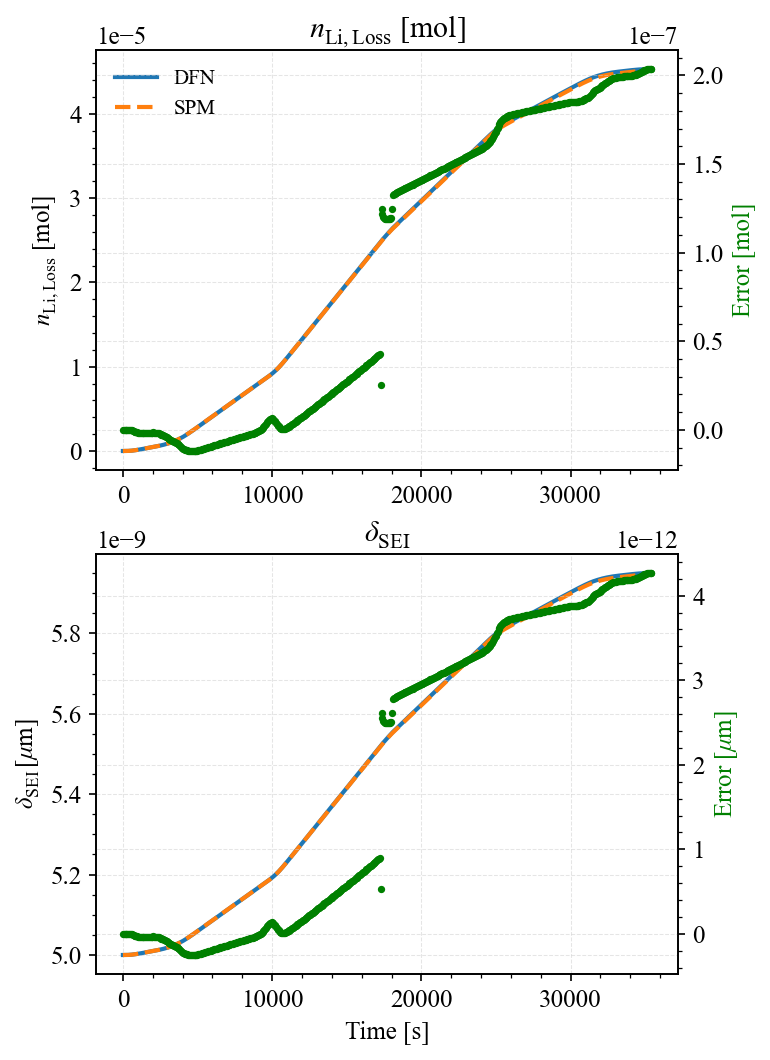

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(t,n_li_loss)
ax1.plot(t_spm,n_li_loss_spm,'--')
ax1.set_title(r"$n_\mathrm{Li,Loss}$ [mol]")
ax1.set_ylabel(r"$n_\mathrm{Li,Loss}$ [mol]")
ax1.legend(["DFN","SPM"])
ax11 = ax1.twinx()
ax11.plot(t,n_li_loss-n_li_loss_spm,"g.")
ax11.set_ylabel("Error [mol]",color="g")
ax2 = ax.flat[1]
ax2.plot(t,delta_sei)
ax2.plot(t_spm,delta_sei_spm,'--')
ax2.set_title(r"$\delta_\mathrm{SEI}$")
ax2.set_ylabel(r"$\delta_\mathrm{SEI}\,[\mu\mathrm{m}]$")
ax21 = ax2.twinx()
ax21.plot(t,delta_sei-delta_sei_spm,"g.")
ax21.set_ylabel(r"Error [$\mu$m]",color="g")
ax2.set_xlabel("Time [s]")
fig.savefig(fig_DIR+"single_cycle_comp_sei_vars_2.png")